Dowloading Dependecies

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

## 1. Preparing data

Read Data

In [2]:
from scipy.io import wavfile
samplerate, data = wavfile.read('./acc1/chord.wav')

helper function to cut unintresting signal

In [3]:
def first_index_bigger_than_absolute_of_a(arr, a):
    indices = np.where(np.abs(arr) > a)[0]  # Get indices where values are higher than 'a'
    return indices[0] if indices.size > 0 else -1  # Return first index or -1 if not found


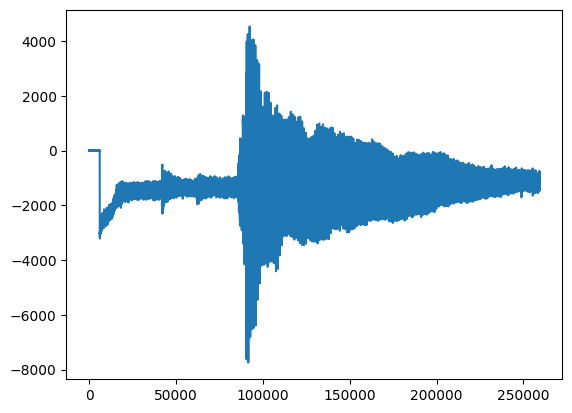

In [4]:
plt.plot(data)

Cut and center signal

In [5]:
start_cut = first_index_bigger_than_absolute_of_a(data,20)
data = data[start_cut:]
data = data - np.mean(data)

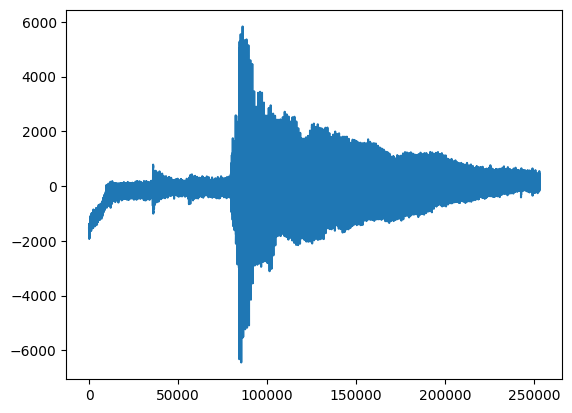

In [6]:
plt.plot(data)

Plot signal in time \
Samplerate - samples/s

In [7]:
number_sample = np.arange(0, len(data))
time = number_sample * 1/samplerate

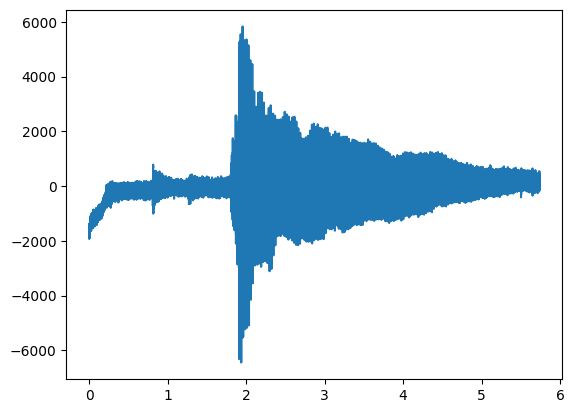

In [8]:
plt.plot(time, data)

In [9]:
np.save('chord')

TypeError: save() missing 1 required positional argument: 'arr'

## 2. Signal Analysis

### 2.1 Fourier Transform

In [9]:
N = len(data)

In [10]:
ffted_signal = scipy.fft.fft(data)

In [11]:
freq = np.fft.fftfreq(len(data), d=1/samplerate)[1:N//2]

(-10.0, 1000.0)

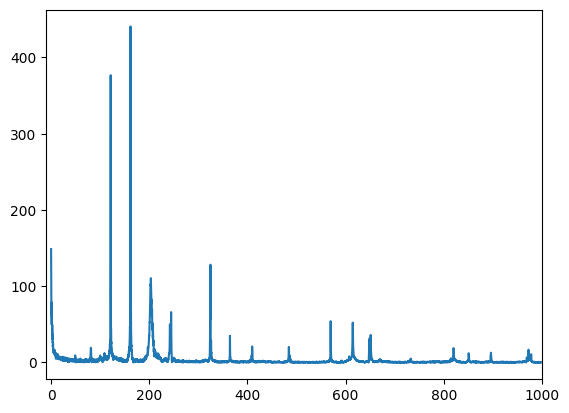

In [12]:
plt.plot(freq, 2/N * np.abs(ffted_signal[1:N//2]))
plt.xlim(-10, 1000)

### 2.2 Power spectrum density

In [13]:
power_spectrum = np.abs(ffted_signal[1:N//2])**2 / N
psd_db = 10 * np.log10(power_spectrum+ 1e-10)

In [14]:
# Select frequency range 16 Hz - 4 kHz
freq_mask = (freq >= 16) & (freq <= 4000)
frequencies = freq[freq_mask]
psd_db = psd_db[freq_mask]

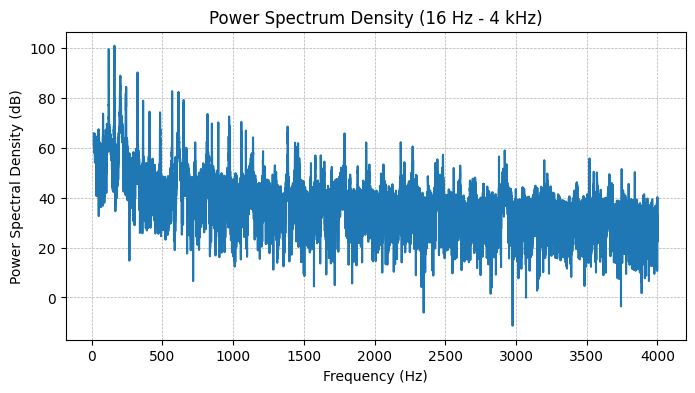

In [15]:
# Plot Power Spectral Density (PSD) in dB
plt.figure(figsize=(8, 4))
plt.plot(frequencies, psd_db)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (dB)')
plt.title('Power Spectrum Density (16 Hz - 4 kHz)')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

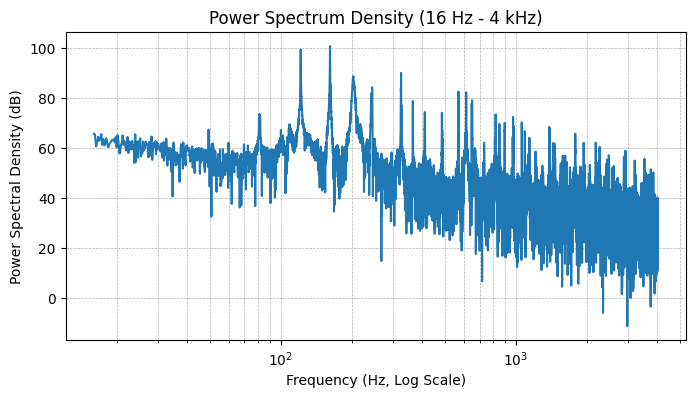

In [16]:
# Plot Power Spectral Density (PSD) in dB
plt.figure(figsize=(8, 4))
plt.semilogx(frequencies, psd_db)  # Log scale for frequency
plt.xlabel('Frequency (Hz, Log Scale)')
plt.ylabel('Power Spectral Density (dB)')
plt.title('Power Spectrum Density (16 Hz - 4 kHz)')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

### 3. Identify sound

In [17]:
# Function to map frequency to closest musical note
def frequency_to_note(freq):
    """Convert a frequency to the closest musical note and return (note, frequency)."""
    A4 = 440.0  # Reference frequency for A4
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    if freq < 16 or freq > 4000:  # Ignore frequencies outside range
        return None
    
    # Compute the number of semitones from A4
    semitone_number = round(12 * np.log2(freq / A4))
    note_index = (semitone_number + 9) % 12  # Adjust to match C=0 in scale
    octave = (semitone_number + 9) // 12 + 4  # Compute octave number
    return f"{note_names[note_index]}{octave}", freq


Identified Notes in the Signal:
B2 (121.52 Hz)
B3 (244.60 Hz)
B4 (484.33 Hz)
C#5 (569.46 Hz)
D#5 (614.38 Hz)
E3 (161.91 Hz)
E4 (324.68 Hz)
E5 (650.94 Hz)
F#4 (364.38 Hz)
G#3 (203.34 Hz)
G#4 (409.64 Hz)


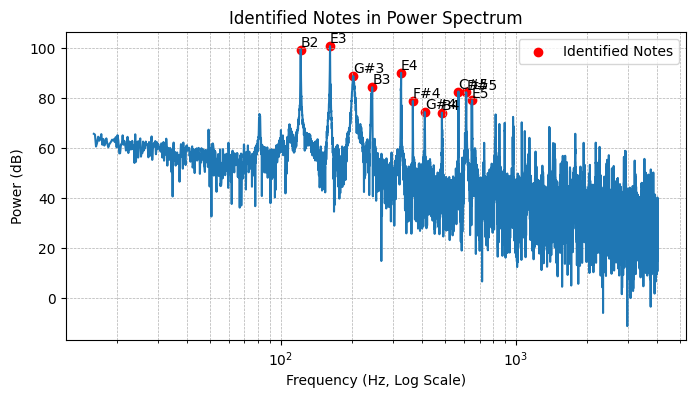

In [18]:
# Set a threshold based on the strongest peak (ignore noise)
threshold = np.max(psd_db) - 27  # 20 dB below max to avoid noise
peaks, _ = scipy.signal.find_peaks(psd_db, height=threshold, distance=50)  # Ensure spaced peaks
peak_frequencies = frequencies[peaks]

# Convert Peak Frequencies to Musical Notes
identified_notes = [frequency_to_note(frequencies[i]) for i in peaks]
identified_notes = sorted(set(filter(None, identified_notes)))  # Remove None & duplicates

# Display Identified Notes
print("Identified Notes in the Signal:")
for note, freq in identified_notes:
    print(f"{note} ({freq:.2f} Hz)")

# Plot Power Spectrum with Identified Notes
plt.figure(figsize=(8, 4))
plt.semilogx(frequencies, psd_db)
plt.scatter(peak_frequencies, psd_db[peaks], color='red', label="Identified Notes")
for note, freq in identified_notes:
    plt.text(freq, psd_db[np.where(frequencies == freq)[0][0]], note, fontsize=10, verticalalignment="bottom")

plt.xlabel('Frequency (Hz, Log Scale)')
plt.ylabel('Power (dB)')
plt.title('Identified Notes in Power Spectrum')
plt.legend()
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

## Answer

The most likely interpretation is that the WAV file contains an **E Major** chord (consisting of E, G#, and B) played on a guitar. This answer is based on the frequency and strength of the peaks.